# Final Project: Data Analysis and Machine Learning Pipeline


## Overview

In this project, you will work with a synthetic dataset and apply the full data science workflow:

1. Data exploration and preparation using Pandas
2. Data cleaning and transformation
3. Exploratory Data Analysis (EDA) and visualization
4. Supervised machine learning using Scikit-learn
5. Model evaluation, comparison, and tuning

The goal is not just to build models, but to understand the impact of data quality, model choice, and evaluation techniques.

## Choose a Dataset

Choose one dataset from the list below.

Dataset Options:
- `bank_loan.csv`
- `ecommerce_customer_behavior.csv`
- `employee_attrition.csv`
- `employee_attrition.csv`
- `hospital_readmission.csv`
- `house_prices.csv`
- `telecom_customer.csv`

## Final Deliverables

### Submit:

1. **Jupyter Notebook**
- Ensure your notebook is well-organized, using multiple cells to separate different tasks and improve readability.
- Include clear, well-commented code throughout.
- Where required, provide a short written analysis using Markdown cells to explain your approach, results, and key insights.

________
# Part 1: Data Cleaning and Preparation
### Due Date : Wednesday April 8th at 11:59pm
## Step 1 – Load and Understand the Dataset (Pandas)

### Tasks

1. Load the libraries you will need.
2. Load the dataset into a Pandas DataFrame.
3. Display:
- First and last 5 rows
- Shape of the dataset
- General information of the data set.
    -  Write a analysis summary of what this gives you.
    -  Note if there are any missing values and in which columns.
  
3. Generate summary statistics for numerical columns.

In [1]:
#Import the libraries
import pandas as pd
import numpy as np

In [11]:
#Step 1: Specify File Path
file_path = 'fitness_tracker.csv'

#Step 2: Read CSV file
df=pd.read_csv(file_path)
df=pd.DataFrame(df)

In [12]:
# Display
# First and last 5 rows
df.head(5)

,user_id,age,steps_per_day,active_minutes,sleep_hours,calories_burned,activity_segment
0,1,40.0,11524.0,100.7,7.82,2594.2,Highly Active
1,2,34.0,2363.0,24.0,7.02,1714.8,LIGHT
2,3,41.0,NaN,79.9,NaN,2202.9,light activity
3,4,50.0,7875.0,90.5,7.59,2290.2,moderately active
4,5,33.0,8048.0,69.6,6.64,2238.8,moderately active


In [13]:
# Get the shape of the DataFrame (attribute)
df.shape


(12120, 7)

In [14]:
# summary
df.info()

# There're 12120 rows and 7 columns. 
# There are missing values in age, steps_per_day, active_minutes,sleep_hours, and calories_burned,
# because their Non-Null Count are less than 12120
# Except user_id is an int and activity_segment is an object, all other varaibles are numeric


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12120 entries, 0 to 12119
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           12120 non-null  int64  
 1   age               11997 non-null  float64
 2   steps_per_day     12000 non-null  float64
 3   active_minutes    12000 non-null  float64
 4   sleep_hours       11999 non-null  float64
 5   calories_burned   11999 non-null  float64
 6   activity_segment  12120 non-null  object 
dtypes: float64(5), int64(1), object(1)
memory usage: 662.9+ KB


In [15]:
# Print the summary statistics of the dataframe using describe()
# Note: if we simply using df.describe(), it will summarize the int column user_id, 
# user_id is a categorical varaible, there's no meaning to summarize mean, std, min, max....
# we only want to get a stats summary of numeric variable
summary=df.describe(include=['float'])
summary

,age,steps_per_day,active_minutes,sleep_hours,calories_burned
count,11997.000000,12000.000000,12000.000000,11999.000000,11999.000000
mean,35.138201,8050.005167,76.832542,7.202662,2270.282474
std,9.622011,2989.603739,25.949091,1.083675,262.383609
min,18.000000,1000.000000,5.000000,4.000000,1500.000000
25%,28.000000,5984.750000,58.900000,6.470000,2090.000000
50%,35.000000,8042.000000,76.700000,7.200000,2271.900000
75%,42.000000,10085.000000,94.500000,7.940000,2447.200000
max,74.000000,23976.000000,175.900000,10.000000,3387.600000


In [16]:
# Check the unique elements in activity_segment-> spelling is messy
pd.unique(df['activity_segment'])

array(['Highly Active', 'LIGHT', 'light activity', 'moderately active',
       'Moderate', 'Moderately Active', 'HIGHLY ACTIVE', 'Lightly Active',
       'highly active'], dtype=object)

In [10]:
# Check the unique individual ID  -> only 12000 individual but 12120, there might be duplicates
pd.unique(df['user_id'])

array([    1,     2,     3, ..., 11998, 11999, 12000], dtype=int64)

## Step 2 – Data Slicing, Subsetting, and Grouping

### Tasks

1. Make a function for each of the following tasks:
    - Select a subset of columns relevant for analysis.
    - Filter rows using logical conditions.
    - Group the data by at least one categorical column.
    - Calculate statistics for each group:
        - Mean
        - Count
        - Standard deviation
  
5. Briefly explain why you made each choice in this step. Describe why the selected columns are relevant to the problem, why specific filtering conditions were applied, and why you grouped the data using a particular categorical variable. Explain how calculating the mean, count, and standard deviation helps compare groups, understand typical behavior, assess group size, and measure variability. Conclude with one or two sentences summarizing what these statistics reveal about the data.
- Note if there are any inconsistencies in the data, this will help you in the next step.

In [18]:
# Suppose: I'm intertesting to see if there's a significant difference in sleep_hours 
# among different active satatus for middle aged (45-65) people
# Make a function called Mid_age_sleep

def Mid_age_sleep(df):
    # I selected the variables age, sleep_hours, and activity_segment 
    # because they are directly relevant to the research question. 
    # Age is needed to define the target population (middle-aged individuals), 
    # sleep_hours is the outcome of interest, and activity_segment represents
    # the grouping variable used to compare different activity levels.
    
    subset1=subset1 = df[['age', 'sleep_hours', 'activity_segment']]
    
    # I filtered the dataset to include only individuals aged between 45 and 65, 
    # which I defined as the middle-aged group. 
    #This allows the analysis to focus specifically on this population 
    # and avoids confounding effects from younger or older age groups.
    
    subset2=subset1[(subset1['age']>=45) & (subset1['age']<=65)]
    
    # I grouped the data by activity_segment to compare sleep patterns across different activity levels. 
    # This grouping helps identify whether activity status is associated with differences in sleep behavior.
    subset2_group= subset2.groupby('activity_segment')
    
    # Mean: Used to measure the average sleep hours and age within each activity group, 
    # providing insight into typical behavior.
    subset2_group_mean=subset2_group.mean(numeric_only=True)
    
    # Count: Indicates the number of individuals in each group, 
    # helping assess the reliability and representativeness of the results.
    subset2_group_count=subset2_group.count() 
    
    # Sd: Measures variability in sleep hours and age,
    # showing how consistent or spread out the values are within each group. 
    subset2_group_sd=subset2_group.std()

    print("Mean age and sleep time for different activity status:")
    print(subset2_group_mean)
    print("\nCount for each activity status:")
    print(subset2_group_count)
    print("\nStandard deviation for each activity status:")
    print(subset2_group_sd)

    return 

In [19]:
Mid_age_sleep(df)


Mean age and sleep time for different activity status:
                         age  sleep_hours
activity_segment                         
HIGHLY ACTIVE      49.913265     7.193077
Highly Active      49.943750     7.176125
LIGHT              49.443114     7.406928
Lightly Active     50.232955     7.255087
Moderate           49.332298     7.157072
Moderately Active  49.785124     7.166233
highly active      49.706587     7.317305
light activity     49.448087     7.276758
moderately active  49.820261     7.208272

Count for each activity status:
                   age  sleep_hours
activity_segment                   
HIGHLY ACTIVE      196          195
Highly Active      160          160
LIGHT              167          166
Lightly Active     176          173
Moderate           322          321
Moderately Active  363          361
highly active      167          167
light activity     183          182
moderately active  306          301

Standard deviation for each activity status:
        

The results show that the average age across all activity groups is approximately 50, and the average sleep duration is around 7.2 hours.  These values are very similar across groups, suggesting that activity status may not significantly influence average sleep time within this middle-aged population. -> need further stats hypothesis testing. Most individuals fall into the Moderately Active group, indicating that this category has the largest sample size. The standard deviation for age is around 4 years, and for sleep duration it is about 1 hour across all groups. This suggests that variability is relatively consistent regardless of activity level. However, the Moderately Active group shows slightly higher standard deviation values, which may indicate greater variation in both age and sleep patterns within this group.

## Step 3 – Data Cleaning and Preparation
### Tasks
1. Identify missing values and report how many exist per column.
2. Handle missing values using one of these methods (Explain why you chose the method):
- Dropping
- Filling with mean/median/mode
  
3. Detect and handle outliers using one of these three methods:
   - Removing Outliers
   - Capping
   - Using sklearn pipeline

*Explain why you chose the method and why is better for your analysis*

4. Identify and remove duplicate records.
5. Fix inconsistent data in a categorical column:
- Standardize text values
- Convert data types if necessary

6. **Re-run the functions from Step 2** using the cleaned dataset. Compare the statistical results with those from the original, unclean dataset. Briefly describe how the statistics changed and explain how cleaning and preparing the data improves the accuracy and reliability of your analysis.

In [20]:
# In step 1, we have identify all the missing values are in numeric cloumns from df.info(). 
# 123 missing values in age, 120 in steps_per_day & active_minutes, and 121 in sleep_hours & calories_burned
# Around 120 missing values over 12k data, it's not a big protion (<= 5%) of data, I'd prefer to drop the missing values, 
# so the future stats models can be more acuurate 

df_cleaned = df.dropna()
df_cleaned.shape

# Also the result shows that rows are reduced to 11527 from  12120, we removed 4.8% of the data, for the rule of thrumb, it's still less than 5%.
# So it's okay to remove them than trying to filling them with 0 


(11527, 7)

In [21]:
# In statistical analysis, we don't normally remove an outlier even after fitting the model
# The IRQ analysis is more for EDA, where we can observe outlier for each varaible. Note: bar plot can show Q1, Q2, Q3,IQR, and outliers.
# If we find some extreme outlier, we'll get back to do quality control analysis.
# Here, I'll just cap them. Let's define a function called handle_outliers. 

def handle_outliers(df):
    df_capped = df.copy()
    
    for column in df_capped.columns:
        if np.issubdtype(df_capped[column].dtype, np.number):
            q1 = df_capped[column].quantile(0.25)
            q3 = df_capped[column].quantile(0.75)
            iqr = q3 - q1
            
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

            # Note because I also want to create new columns, I don't want to overwrite the original column, I use df_capped[column + '_capped']
            df_capped[column + '_capped'] = np.where(
                df_capped[column] > upper_bound, upper_bound,
                np.where(df_capped[column] < lower_bound, lower_bound, df_capped[column])
            )
    
    return df_capped





In [6]:
df_capped=handle_outliers(df_cleaned)
df_capped.head(5)

,user_id,age,steps_per_day,active_minutes,sleep_hours,calories_burned,activity_segment,user_id_capped,age_capped,steps_per_day_capped,active_minutes_capped,sleep_hours_capped,calories_burned_capped
0,1,40.0,11524.0,100.7,7.82,2594.2,Highly Active,1.0,40.0,11524.0,100.7,7.82,2594.2
1,2,34.0,2363.0,24.0,7.02,1714.8,LIGHT,2.0,34.0,2363.0,24.0,7.02,1714.8
3,4,50.0,7875.0,90.5,7.59,2290.2,moderately active,4.0,50.0,7875.0,90.5,7.59,2290.2
4,5,33.0,8048.0,69.6,6.64,2238.8,moderately active,5.0,33.0,8048.0,69.6,6.64,2238.8
5,6,33.0,8541.0,75.8,6.81,2305.2,Moderate,6.0,33.0,8541.0,75.8,6.81,2305.2


In [22]:
# In step 1, we also notice the potential duplicates by seeing the output from pd.unique(df['user_id'])

duplicate_row=df_capped[df_capped.duplicated()]
print("duplicates rows: \n",duplicate_row)

df_without_duplicates=df_capped.drop_duplicates()
print("Data frame withiout duplicates: \n",df_without_duplicates)



duplicates rows: 
        user_id   age  steps_per_day  active_minutes  sleep_hours  \
12009     1174  34.0         9527.0            85.7         6.94   
12011     2489  35.0         5078.0            42.9         7.81   
12018    10283  45.0         5075.0            36.2         7.33   
12022     2228  29.0         7298.0            71.5         8.21   
12023     4641  43.0         8239.0            83.3         5.46   
12024     3506  21.0         7799.0            79.8         6.51   
12025     8549  31.0         7585.0            79.7         5.73   
12028    11223  34.0         7697.0            63.5         7.03   
12030    11788  46.0        11207.0           102.4         6.31   
12032     5794  36.0         6935.0            69.1         7.21   
12033      823  58.0         8581.0            83.4         6.94   
12035     4804  28.0         6000.0            68.4         8.04   
12039    10897  20.0        10445.0            99.7         6.15   
12047     8102  28.0         

In [23]:
# In step 1, we run pd.unique(df['activity_segment'])
# 'Highly Active', 'LIGHT', 'light activity', 'moderately active',
#'Moderate', 'Moderately Active', 'HIGHLY ACTIVE', 'Lightly Active','highly active'
# We can use a map function to fix it

# Highly Active, HIGHLY ACTIVE, highly active -> Highly Active
# LIGHT, light activity, Lightly Active -> Lightly Active
# moderately active, Moderate, Moderately Active -> Moderately Active

df_standarized = df_without_duplicates
color_mapping = {
    'highly active': 'Highly Active',
    'light': 'Lightly Active',              
    'light activity': 'Lightly Active',
    'lightly active': 'Lightly Active',
    'moderately active': 'Moderately Active',
    'moderate': 'Moderately Active'
}

df_standarized['activity_segment'] = df_without_duplicates['activity_segment'].str.lower().str.strip().map(color_mapping)



pd.unique(df_standarized['activity_segment'])


C:\Users\jy441064\AppData\Local\Temp\ipykernel_35436\1037629571.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_standarized['activity_segment'] = df_without_duplicates['activity_segment'].str.lower().str.strip().map(color_mapping)


array(['Highly Active', 'Lightly Active', 'Moderately Active'],
      dtype=object)

In [24]:
Mid_age_sleep(df_standarized)


Mean age and sleep time for different activity status:
                         age  sleep_hours
activity_segment                         
Highly Active      49.881553     7.221456
Lightly Active     49.838174     7.322282
Moderately Active  49.623323     7.177214

Count for each activity status:
                   age  sleep_hours
activity_segment                   
Highly Active      515          515
Lightly Active     482          482
Moderately Active  969          969

Standard deviation for each activity status:
                        age  sleep_hours
activity_segment                        
Highly Active      4.378444     1.126980
Lightly Active     4.199638     1.032076
Moderately Active  4.170131     1.071193


In [26]:
output_path='Results/fitness_clean.csv'
df_standarized.to_csv(output_path, index=False)

After cleaning the dataset, the results became more consistent and easier to interpret. The activity categories were standardized from nine inconsistent labels into three clear groups: Highly Active, Moderately Active, and Lightly Active.  This removed fragmentation and combined counts correctly. Before cleaning, counts were split across similar labels and sometimes differed between variables  due to missing values or duplicates, making the results less reliable.  After cleaning, counts are consistent within each group, and the Moderately Active group has the largest sample size. The mean age and sleep hours remain very similar across groups both before and after cleaning,  maybe there's no significant difference by activity level. However, the standard deviation is now more reliable, showing similar variability across groups without distortion from inconsistent labels. Overall, data cleaning improves accuracy and ensures more reliable comparisons between groups.

________
# Part 2: Data Visualization and Data Preparation for Machine Learning Analysis
### Due Date : Sunday April 19th at 11:59pm
## Step 1 – Exploratory Data Analysis (EDA)
### Tasks

Create 4 visualizations:
1. Distribution of a numerical variable
2. Relationship between two numerical variables
3. Comparison across categories
4. Correlation visualization

Explain why you chose the visualization type and write a couple sentences analysis of what each visualization is telling you. 

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df_standarized=pd.read_csv('Results/fitness_clean.csv')

In [21]:
df_standarized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11481 entries, 0 to 11480
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 11481 non-null  int64  
 1   age                     11481 non-null  float64
 2   steps_per_day           11481 non-null  float64
 3   active_minutes          11481 non-null  float64
 4   sleep_hours             11481 non-null  float64
 5   calories_burned         11481 non-null  float64
 6   activity_segment        11481 non-null  object 
 7   user_id_capped          11481 non-null  float64
 8   age_capped              11481 non-null  float64
 9   steps_per_day_capped    11481 non-null  float64
 10  active_minutes_capped   11481 non-null  float64
 11  sleep_hours_capped      11481 non-null  float64
 12  calories_burned_capped  11481 non-null  float64
dtypes: float64(11), int64(1), object(1)
memory usage: 1.1+ MB


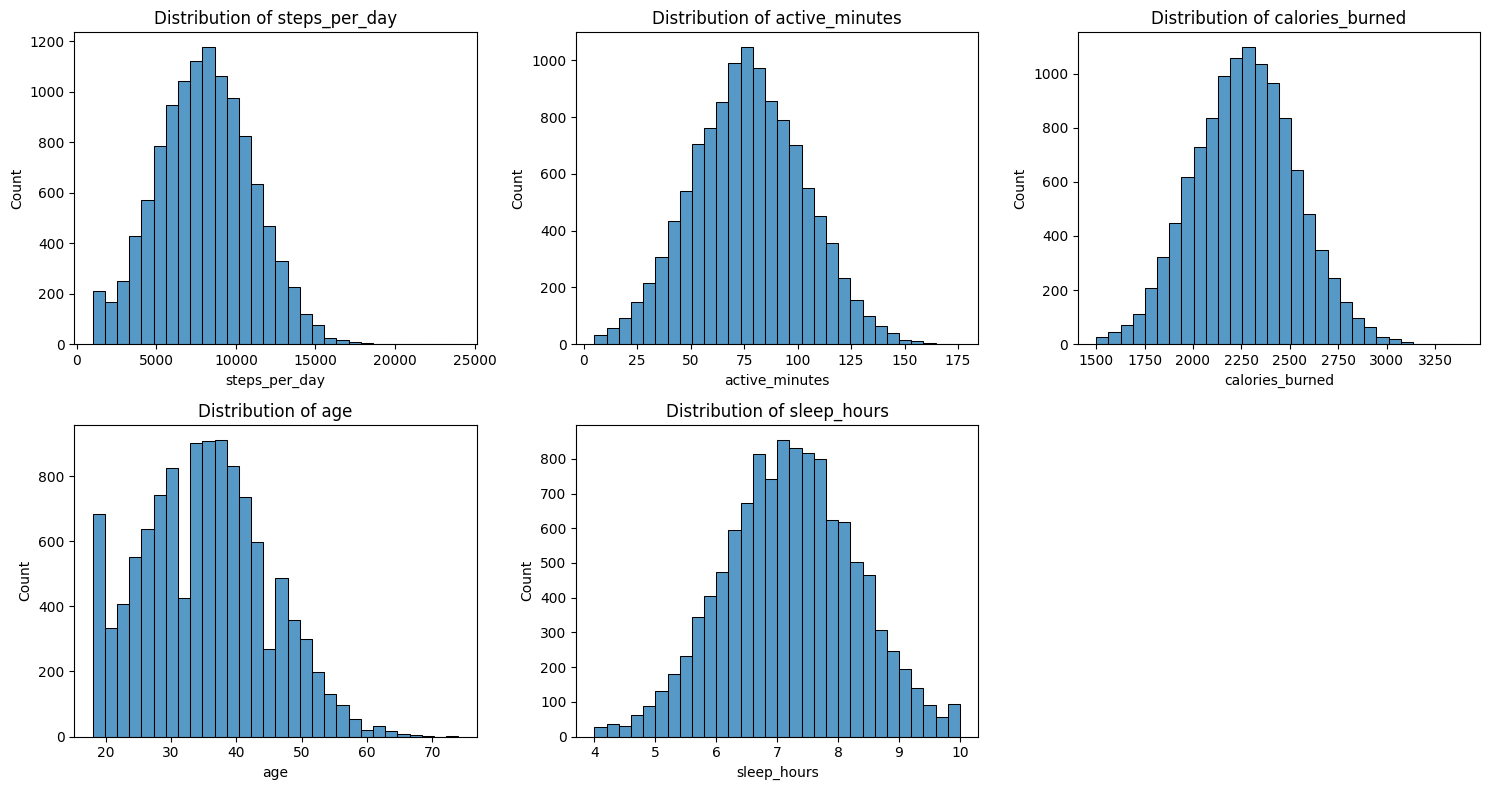

In [94]:
# 1. Distribution of numerical variables 
plt.figure(figsize=(15, 8))

num_features = ['steps_per_day', 'active_minutes', 'calories_burned', 'age', 'sleep_hours']

for i, col in enumerate(num_features):
    plt.subplot(2, 3, i+1)
    sns.histplot(data=df_standarized, x=col, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


I examined the histograms of all numerical variables to understand their distributions, including potential skewness and differences in scale. This is important because variables on very different scales may require transformation or standardization before modeling. In addition, identifying the shape of each distribution helps guide decisions about handling missing values—for example, whether to use the mean, median, or another imputation method.
Understanding the distribution of the response variable is also essential for model selection. If the response is continuous, its distribution (e.g., normal, skewed, or heavy-tailed) can inform which statistical models are appropriate.

For e.g., if we are intertesed in predicting sleep hours, then in this case, the histogram shows that sleep_hours is approximately normally distributed, with most values concentrated around 7 hours. This suggests that models assuming normality, such as linear regression, may be appropriate for predicting sleep duration.

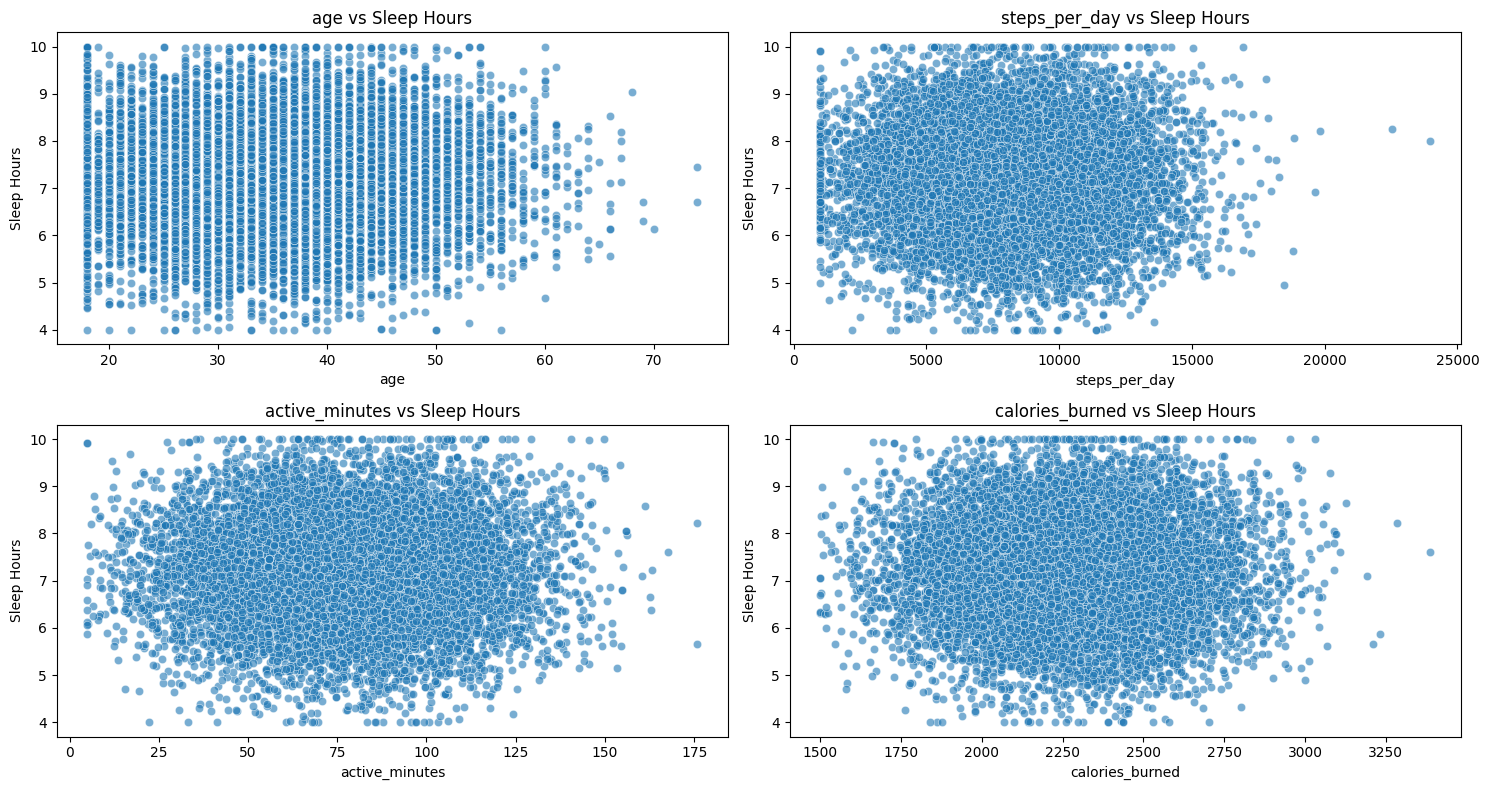

In [95]:
# 2. Relationship between two numerical variables 

plt.figure(figsize=(15, 8))

x_vars = ['age', 'steps_per_day', 'active_minutes', 'calories_burned']

for i, col in enumerate(x_vars):
    plt.subplot(2, 2, i+1)
    sns.scatterplot(data=df_standarized, x=col, y='sleep_hours', alpha=0.6)
    plt.title(f'{col} vs Sleep Hours')
    plt.xlabel(col)
    plt.ylabel('Sleep Hours')

plt.tight_layout()
plt.show()


I first used a scatter plot to explore the relationship between age and sleep_hours, as it allows us to visually assess patterns, trends, and potential non-linear relationships between two continuous variables.

The plot suggests that the relationship between age and sleep hours is not strongly linear. Younger individuals show greater variability in sleep duration (ranging roughly from 4 to 10 hours), while older individuals tend to have a narrower range of sleep (around 5.5 to 8.5 hours). This indicates that sleep patterns may become more consistent with age. There are no obvious linear relationship between step, act_min, cal_burned and sleep_hour either.

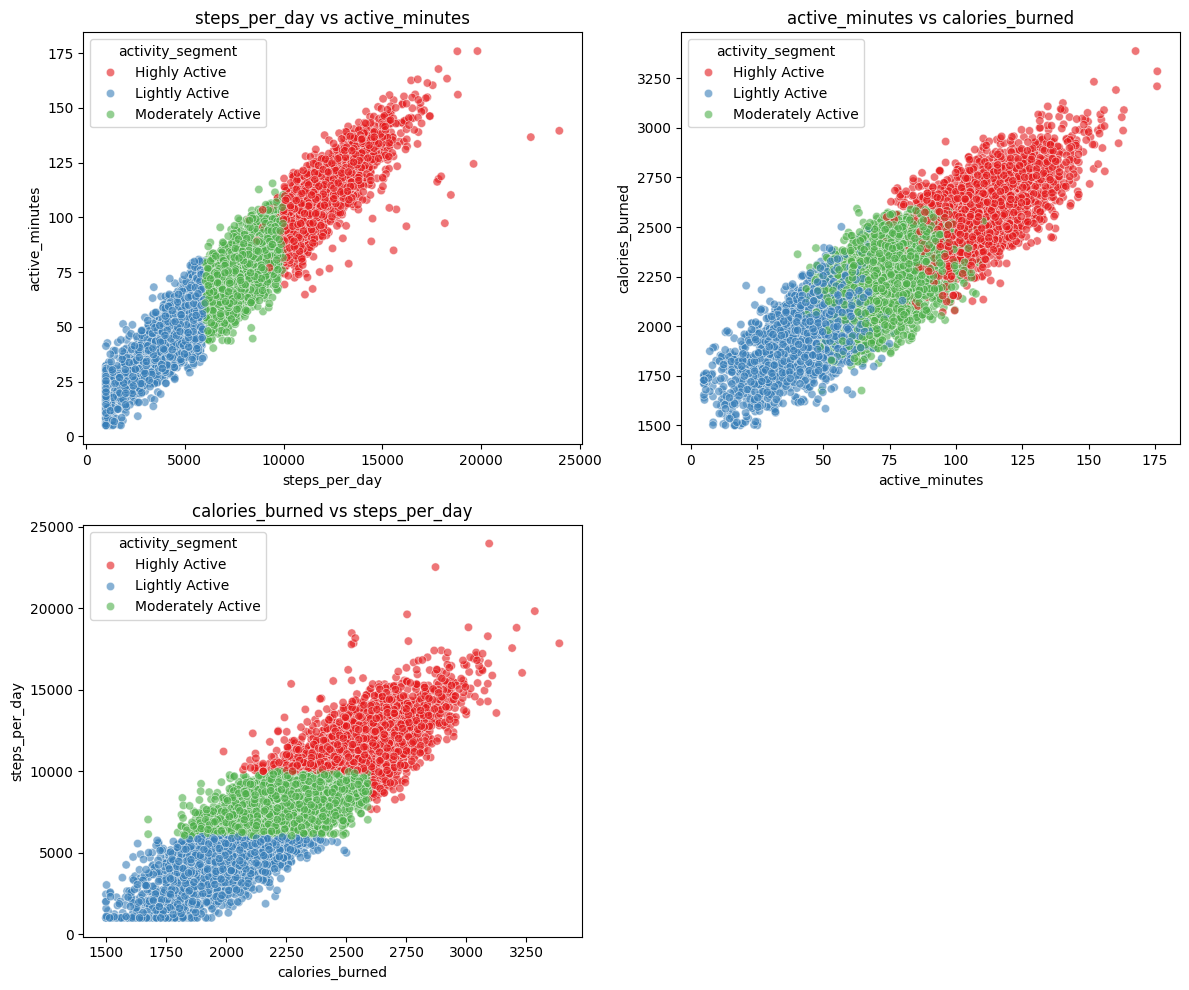

In [98]:
plt.figure(figsize=(12, 10))

pairs = [
    ('steps_per_day', 'active_minutes'),
    ('active_minutes', 'calories_burned'),
    ('calories_burned', 'steps_per_day')
]

for i, (x_col, y_col) in enumerate(pairs):
    plt.subplot(2, 2, i+1)
    sns.scatterplot(data=df_standarized, x=x_col, y=y_col, alpha=0.6,hue='activity_segment',
    palette='Set1')
    plt.title(f'{x_col} vs {y_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)

plt.tight_layout()
plt.show()

From the scatter plots of steps_per_day, active_minutes, and calories_burned (grouped by activity segment), we observe strong positive linear relationships among these three variables. The plots also show clear separation between activity groups: individuals in the Highly Active group consistently have higher values across all three variables, while the Moderately Active group falls in the middle, and the Lightly Active group has the lowest values.



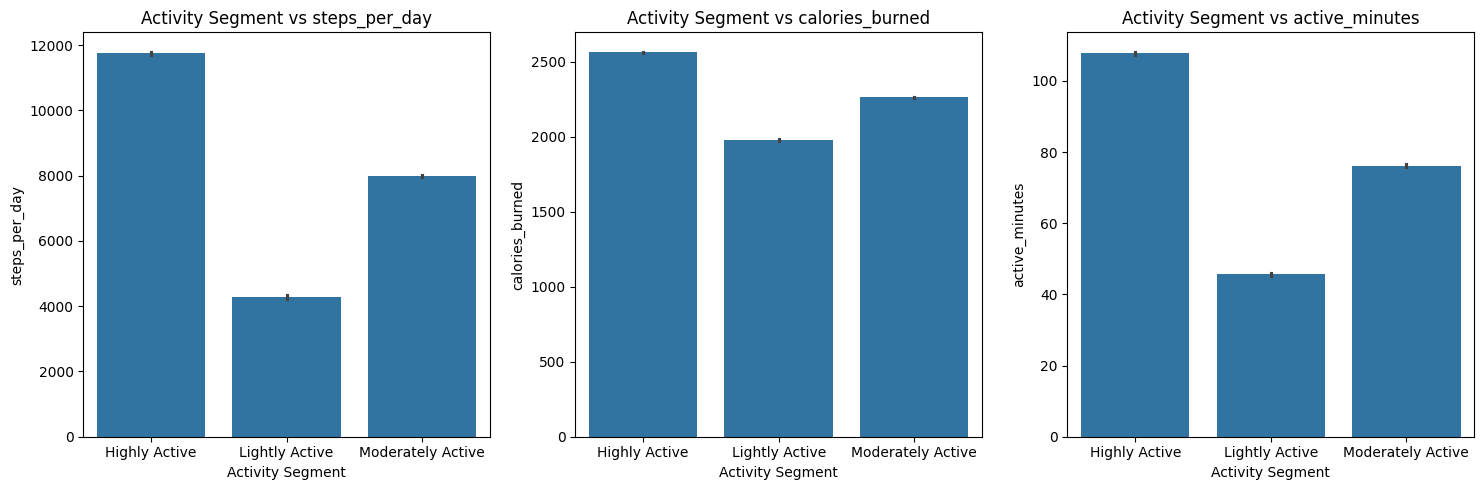

In [101]:
# 3. Comparison across categories (Bar plot: activity_segment vs steps_per_day, calories_burned, active_minutes)

plt.figure(figsize=(15, 5))

y_vars = ['steps_per_day', 'calories_burned', 'active_minutes']

for i, col in enumerate(y_vars):
    plt.subplot(1, 3, i+1)
    sns.barplot(data=df_standarized, x='activity_segment', y=col)
    plt.title(f'Activity Segment vs {col}')
    plt.xlabel('Activity Segment')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

To further examine these differences, bar plots were used to compare average values across activity levels. The results show that steps_per_day and active_minutes differ substantially across the three groups, with clear increases from Lightly Active to Highly Active. Although the differences in calories_burned are relatively smaller in comparison, they are still noticeable and follow the same overall trend.

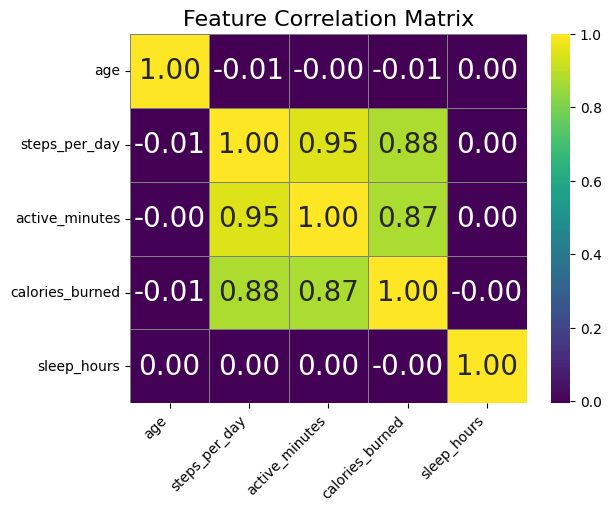

In [102]:
# 4. Correlation plot 
continous_var = df_standarized[['age', 'steps_per_day', 'active_minutes', 'calories_burned','sleep_hours']]
sns.heatmap(continous_var.select_dtypes(include=[np.number]).corr(), 
            annot=True, cmap='viridis', fmt='.2f',
            annot_kws={"size": 20},  # Adjust annotation font size
            linewidths=0.5, linecolor='gray')  # Add gridlines for spacing
plt.title('Feature Correlation Matrix', fontsize=16)  # Increase title font size
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate x-axis labels for readability
plt.yticks(fontsize=10)  # Adjust y-axis label font size
plt.show()


From the correlation matrix, there is a strong positive correlation (greater than 0.7) among steps_per_day, active_minutes, and calories_burned, indicating the presence of multicollinearity. Including highly correlated variables in the same model is not recommended, as it can distort coefficient estimates and reduce model interpretability.

Additionally, these three variables represent different aspects of physical activity and therefore capture similar underlying information. As a result, it would be more appropriate to select only one of them, or use a combined measure (such as activity_segment), when building the model.

In contrast, age and sleep_hours show very weak correlations with the other variables, suggesting that they are largely independent and may contribute different information to the analysis.



Text(0.5, 1.0, 'Interaction between age & activity segment for sleep hours')

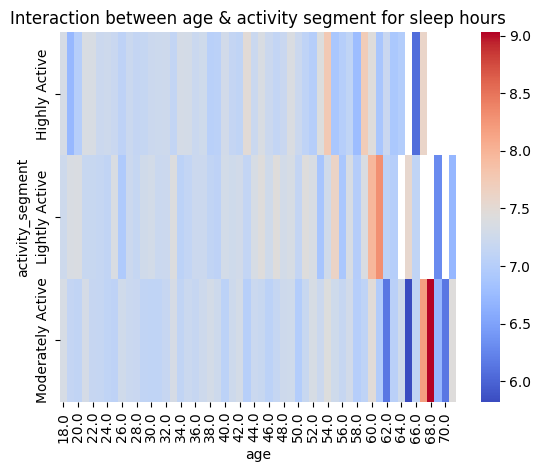

In [42]:
# 5. Interaction visualization (Heatmap: age × activity_segment) -> just for my own curiosity

corr_matrix=df_standarized.pivot_table(index='activity_segment', columns='age', values='sleep_hours')

# Create a heatmap
sns.heatmap(corr_matrix, cmap='coolwarm')

# Add a title
plt.title('Interaction between age & activity segment for sleep hours')



I used a heatmap to examine the interaction between age and activity_segment in relation to sleep hours. This type of visualization helps identify patterns across two dimensions and highlights how values vary across combinations of variables.

The heatmap shows that before age 50, sleep patterns are relatively similar across activity levels. Between ages 50 and 60, the moderately active group appears to have slightly lower average sleep. For older ages (60–70), there are some gaps in the data for certain activity levels, but the moderately active group shows a wider range of sleep values. Overall, the interaction between age and activity level does not show a strong or consistent effect on sleep duration.

## Step 2 – Prepare Data for Machine Learning
### Tasks
1. Select features (X) and target (y).
2. Encode categorical variables if needed.
3. Split the dataset into training and testing sets
4. Clearly explain why you chose the target variable.

From Step 1, we kinda explore that steps_per_day, active_minutes, and calories_burned collectively may be avle to represent the underlying concept of activity_segment. To evaluate that, we can test whether these variables are able to predict or classify the activity segment. 

Therefore, in this model, the features (X) are steps_per_day, active_minutes, and calories_burned, while the target variable (y) is activity_segment. If the model performs well, it would support the idea that these variables capture similar information and can serve as a combined measure of activity level.


In [66]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,RobustScaler
from sklearn.compose import ColumnTransformer
# from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import 
from sklearn.model_selection import cross_val_score #CV function
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold

from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from skopt.plots import plot_convergence

C:\Users\jy441064\AppData\Local\Temp\ipykernel_12884\2517342600.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_standarized, x='activity_segment', y=col, palette='viridis')
C:\Users\jy441064\AppData\Local\Temp\ipykernel_12884\2517342600.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_standarized, x='activity_segment', y=col, palette='viridis')
C:\Users\jy441064\AppData\Local\Temp\ipykernel_12884\2517342600.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_standarized, x='activity_segment', y=col, palette='vi

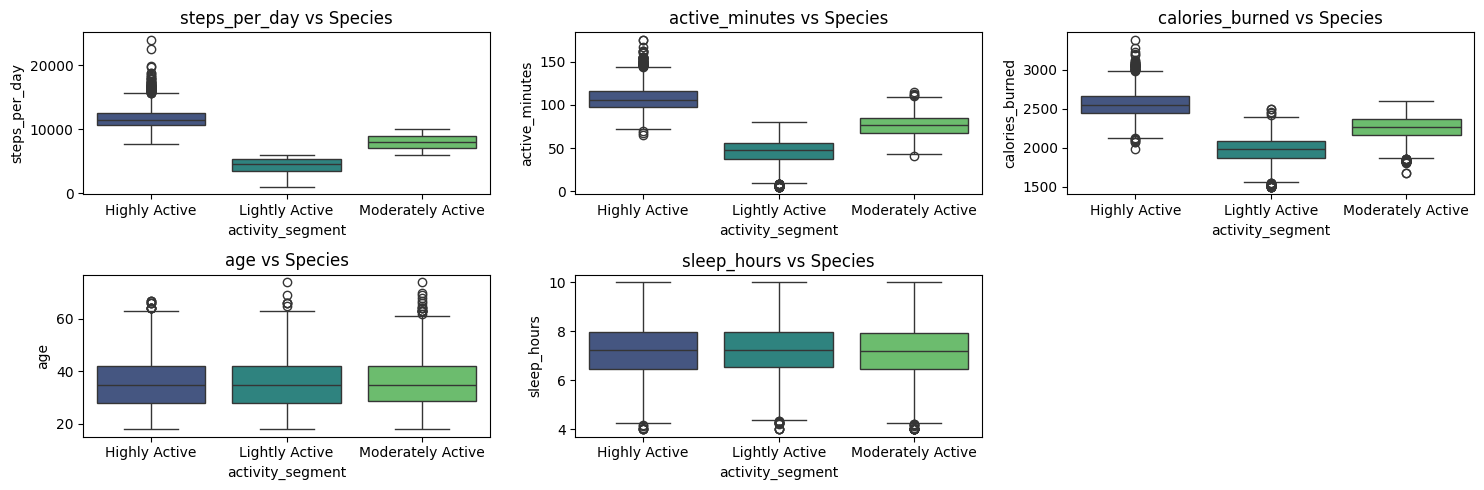

In [23]:
# Analogue to Correlation Matrix for Numerical Features vs Categorical Target
plt.figure(figsize=(15, 5))
num_features = ['steps_per_day', 'active_minutes',  'calories_burned', 'age', 'sleep_hours']

for i, col in enumerate(num_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=df_standarized, x='activity_segment', y=col, palette='viridis')
    plt.title(f'{col} vs Species')

plt.tight_layout()
plt.show()

First, I used boxplots to visually examine how all continuous variables vary across different activity_segment groups. The boxplots show clear differences for the first three variables—steps_per_day, active_minutes, and calories_burned. For example, the medians of these variables are substantially higher in the Highly Active group compared to the other groups, indicating strong separation across activity levels.

In contrast, age and sleep_hours do not show noticeable differences across activity segments, suggesting that these variables are not strongly associated with activity level.

In [24]:
### DATA PREPROCESSING ###

# define X and y
features = ['steps_per_day', 'active_minutes',  'calories_burned','age', 'sleep_hours']
target = ['activity_segment']

X = df_standarized[features]
y = df_standarized[target]

# define column types
numerical_cols = ['steps_per_day', 'active_minutes',  'calories_burned','age', 'sleep_hours']


# pipelines
num_pipeline = Pipeline([
('scaler', StandardScaler())
]) # From part 1, we have already chose to drop all the NA values, so we don't need to impute here.
   # Becuase we only droped less than 5% of the data, in most cases, we can either choose to drop NA or impute the unknown. 
   # But our response varaible activity_segment also has missing values, it's better to drop NA than imputing the unknown.



# combine
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_cols)
])

In [25]:
### DATA SPLITTING FOR TRAINING ###

# split into training and testing. DO THIS BEFORE FITTING PREPROCESSOR
X_train, X_val, y_train, y_val = train_test_split(X,
                                                  y,
                                                  test_size=0.3,
                                                  shuffle = True,
                                                  random_state=33)

# # preprocess features, this converts them to numpy arrays
X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)

## Step 3 – Supervised Learning Models

### Choose one of the models below and train it:
1. Regression model (if dataset supports it)
2. Classification model
3. K-Nearest Neighbours (KNN)

### Tasks
1. Train the model on the training dataset.
2. Generate predictions on the test dataset.
3. Store predictions for comparison.

In [26]:
# I choose the random forest classifier model because activity_segment is a categorical varaible 
rf_clf = RandomForestClassifier(
    n_estimators=100,      # Number of trees.
    max_depth=10,          # Depth of trees to prevent overfitting.
    min_samples_split=5,   # Minimum samples to split a node.
    max_features='sqrt',   # "sqrt" is the industry standard for classification.
    criterion='gini',      # The mathematical method to measure "purity" of a split.
    random_state=1999,     # For reproducibility.
    n_jobs=-1,             # Use all CPU cores.
    verbose=1              # Progress updates.
)

In [27]:
# fit model and make predictions
rf_clf.fit(X_train, y_train.values.ravel())

y_val_pred = rf_clf.predict(X_val)
y_train_pred = rf_clf.predict(X_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


________
# Part 3: Machine Learning Analysis
### Due Date : Sunday May 3rd at 11:59pm

## Step 1 – Model Evaluation and Metrics
### Tasks
Evaluate the model:
   1. If a classification model was selected:
        - Calculate Accuracy
        - Generate the Confusion Matrix
        - Calculate Precision
        - Briefly explain what each metric tells you about model performance.
  1. If a Regression Model was selected:
        - Compute appropriate regression metrics (e.g., MAE, RMSE, R²).
        - Interpret what these values indicate about prediction quality.

In [28]:
def classification_eval(y_train,y_train_pred,y_val,y_val_pred):

    # calculate accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    print(f"Training   | Accuracy: {train_acc:.4f}")
    print(f"Validation | Accuracy: {val_acc:.4f}\n")

    # performance breakdown
    print("--- Validation Classification Report ---")
    print(classification_report(y_val, y_val_pred))

    # confusion matrix
    disp = ConfusionMatrixDisplay.from_predictions(
        y_val, 
        y_val_pred, 
        cmap='Blues', 
        xticks_rotation=45
    )
    plt.title("Confusion Matrix: Activity Segment Prediction")
    plt.show()

    return

Training   | Accuracy: 1.0000
Validation | Accuracy: 0.9997

--- Validation Classification Report ---
                   precision    recall  f1-score   support

    Highly Active       1.00      1.00      1.00       907
   Lightly Active       1.00      1.00      1.00       880
Moderately Active       1.00      1.00      1.00      1658

         accuracy                           1.00      3445
        macro avg       1.00      1.00      1.00      3445
     weighted avg       1.00      1.00      1.00      3445



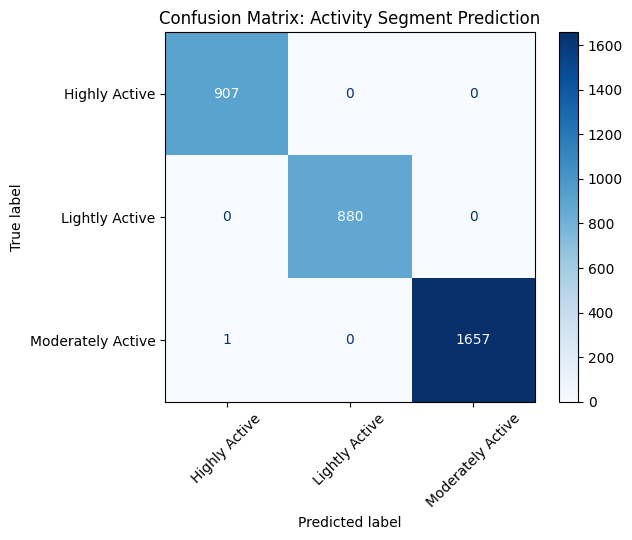

In [29]:
classification_eval(y_train,y_train_pred,y_val,y_val_pred)

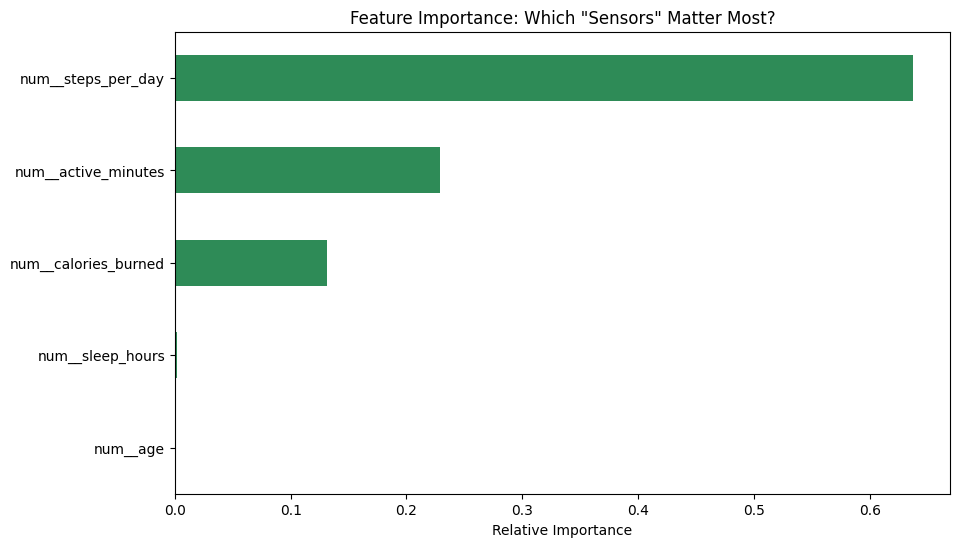

In [30]:
# Extract names from the preprocessor (which handles the one-hot encoding names)
feature_names_out = preprocessor.get_feature_names_out()

# Create the series
importances = pd.Series(rf_clf.feature_importances_, index=feature_names_out)

# Plot the top 10 most influential features
plt.figure(figsize=(10, 6))
importances.sort_values(ascending=True).tail(10).plot(kind='barh', color='seagreen')
plt.title('Feature Importance: Which "Sensors" Matter Most?')
plt.xlabel('Relative Importance')
plt.show()

## Step 2 – Overfitting, Underfitting, and Cross-Validation
### Tasks
1. Explain overfitting and underfitting using your results.
- Define overfitting and underfitting in your own words.
- Use your model’s training and test results to determine whether either issue is present.

2. Apply Cross-Validation:
- K-Fold Cross Validation
  
3. Compare and Interpret Results <font color='red'> I don't think we really need this step. We used the model we have chosen, we just need to check the Mean CV accuracy, because each fold will give you a confusion matrix.
- Choose an appropriate evaluation metric for your model (e.g., **accuracy, precision, recall, F1-score** for classification, or **R², RMSE** for regression).  
- Report the **mean cross-validation score** for your chosen metric.  
- Compare the cross-validation performance to your **test-set performance** using the same metric.  
- Discuss whether the model **generalizes well** or shows signs of **overfitting or underfitting** based on these results.  

- Overfitting: A model learns the training data too well, including noise, and fails to generalize to new data.
- Underfitting: A model is too simple and fails to capture the underlying pattern in the data.


My model: Training accuracy = 1.0000, Validation accuracy = 0.9997
There's no gap so doesn't look like classic overfitting, but it does look like a data leakage or an overly easy data.

So I used 5-fold cv to check if there's overfitting. The model does not show classical overfitting because the accuracy is still very high, as training and validation accuracy are both extremely high and nearly identical. However, such near-perfect performance is unusual for real-world datasets. I guess it is because this dataset is way to simple and is simulated by an alogrithm.

In [67]:

# Use my defined model to do a CV
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    max_features='sqrt',
    criterion='gini',
    random_state=1999,
    n_jobs=-1
)

# CV function

cv_scores = cross_val_score(
    rf_clf,
    X,
    y.values.ravel(),
    cv=5,
    scoring='accuracy'
)

print("CV scores:", cv_scores)
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Std CV accuracy: {cv_scores.std():.4f}")



CV scores: [1.         0.99956446 1.         1.         0.99956446]
Mean CV accuracy: 0.9998
Std CV accuracy: 0.0002



Fold 1 accuracy: 0.9996


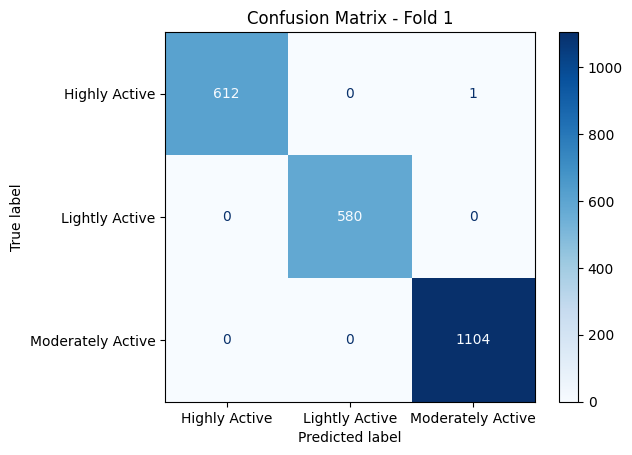


Fold 2 accuracy: 1.0000


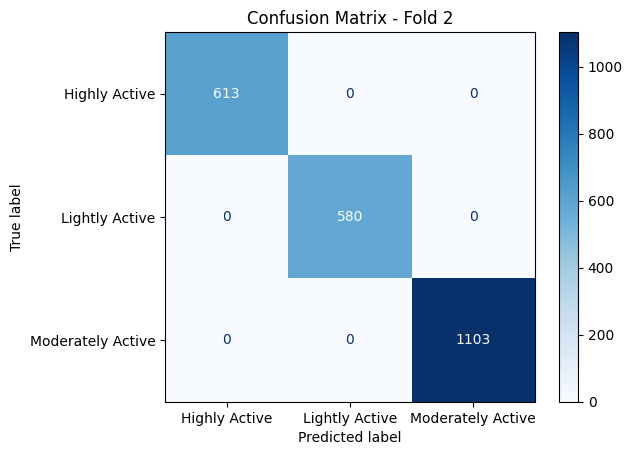


Fold 3 accuracy: 0.9996


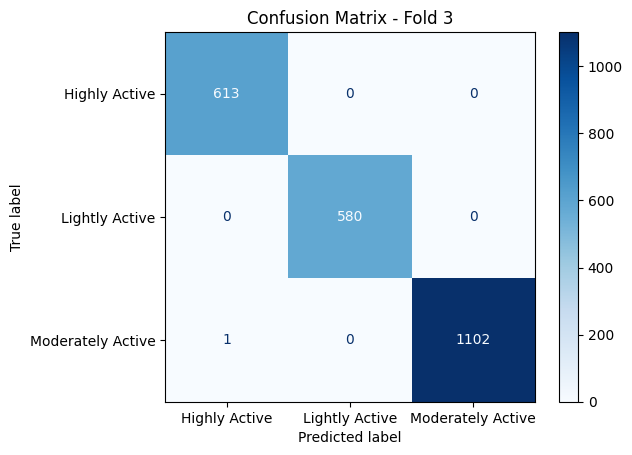


Fold 4 accuracy: 1.0000


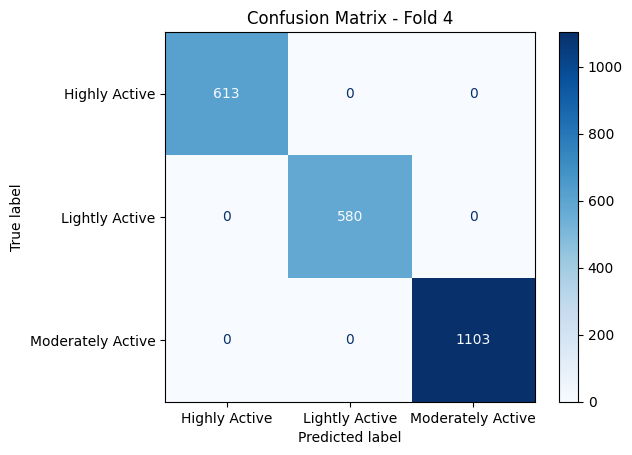


Fold 5 accuracy: 0.9996


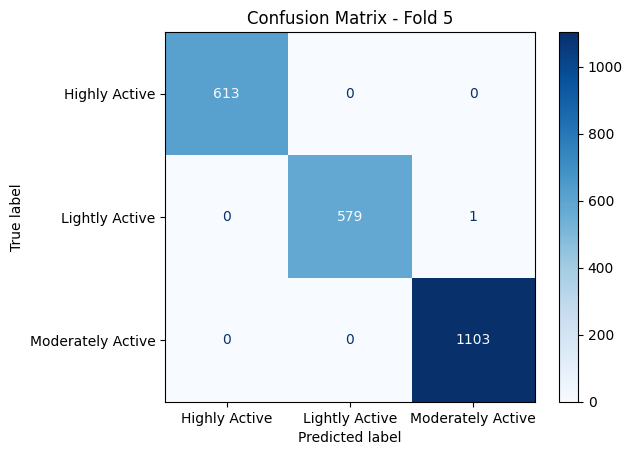

In [71]:

# Each fold was evaluated separately to assess stability of classification errors across different data partitions.
# To see how each fold perform we can create a list of confusion matrices

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1999)

fold = 1
cv_scores = []

for train_idx, val_idx in cv.split(X, y): #use the whole dataset for CV

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # fit model
    rf_clf.fit(X_tr, y_tr.values.ravel())

    # predictions
    y_val_pred = rf_clf.predict(X_val)

    # accuracy
    acc = accuracy_score(y_val, y_val_pred)
    cv_scores.append(acc)

    print(f"\nFold {fold} accuracy: {acc:.4f}")

    # confusion matrix for each fold
    ConfusionMatrixDisplay.from_predictions(
        y_val,
        y_val_pred,
        cmap='Blues'
    )
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.show()

    fold += 1




The CV results provide additional insight into the model’s classification behavior across different data splits. Across the 5 folds, only a small number of misclassifications were observed. In particular, fold 1 showed a high activity sample misclassified as moderate, fold 3 showed a moderate sample misclassified as high, and fold 5 showed a lightly active sample misclassified as moderate. These errors are consistent with the structure of the data, where class boundaries appear to overlap in the feature space, particularly between the moderately active class and the adjacent classes.

Overall, the model maintains extremely high performance across all folds, with a mean cross-validation accuracy of approximately 0.9998, indicating strong stability and predictive power.

*Note*: Compared to the single train-test split, CV provides a more robust estimate of model performance because each observation is used for both training and validation across different folds. This reduces dependence on a single data split and provides a more reliable assessment of generalization ability.

While both CV and train-test evaluation produce very similar accuracy results, slight differences in misclassification patterns are expected due to variations in training subsets across folds. In the train-test split, only one misclassification was observed, whereas cross-validation reveals different but consistent types of errors across folds. This variation is normal and reflects the model’s sensitivity to slight changes in training data rather than instability.

## Step 3 – Hyperparameter Tuning

### Tasks

1. Hyperparameter Optimization
- Use the model you chose before (regression or classification).
- Define a search space for the model’s key hyperparameters.
- Apply both:
  - **Grid Search** to test all combinations of hyperparameters.
  - **Bayesian Optimization** to efficiently explore the search space.
    - Briefly explain why you chose a particular prior or distribution for each hyperparameter (e.g., uniform, log-uniform).
- Identify the best hyperparameters from each method.
- Compare the results and check if both methods produce similar optimal values.

2. Fit the Final Model
- Train the model using the best hyperparameters found.
- Evaluate performance on both **training** and **test** datasets.
  - Comment on any differences in performance between training and test sets (e.g., whether the model is overfitting or well generalized).

3. Visualize Model Performance <font color='red'> I don't think this works for classifcation model. For classfication model, confusion matrix is enough
- Create a **Predicted vs Actual** scatter plot:
  - Plot predicted values against true values.
  - Include a reference line (*y = x*) to assess prediction accuracy.
- Interpret how well the model performs based on the plot.

In [51]:

### GRID SEARCH

# define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

# base model (classification)
rf_base = RandomForestClassifier(
    random_state=1997,
    n_jobs=-1
)

# grid search
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',   
    verbose=2,
    n_jobs=-1
)

# fit
grid_search.fit(X_train, y_train.values.ravel())

# print results
print("GRID SEARCH RESULTS")
print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")




Fitting 5 folds for each of 36 candidates, totalling 180 fits
GRID SEARCH RESULTS
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV Accuracy: 0.9993


Training   | Accuracy: 1.0000
Validation | Accuracy: 0.9991

--- Validation Classification Report ---
                   precision    recall  f1-score   support

    Highly Active       1.00      1.00      1.00       907
   Lightly Active       1.00      1.00      1.00       880
Moderately Active       1.00      1.00      1.00      1658

         accuracy                           1.00      3445
        macro avg       1.00      1.00      1.00      3445
     weighted avg       1.00      1.00      1.00      3445



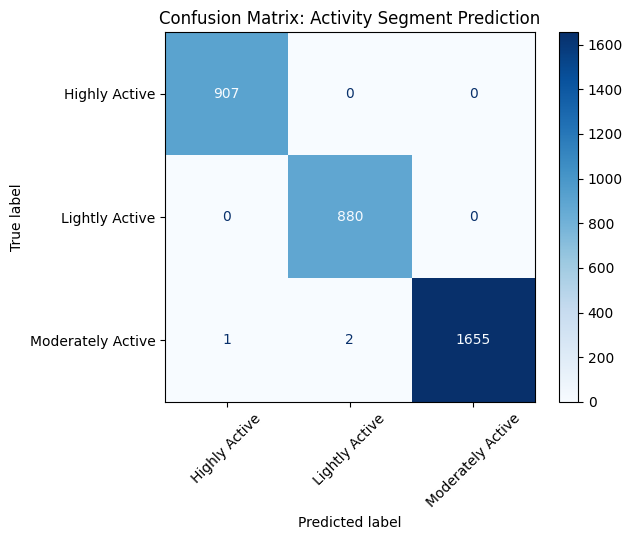

In [52]:
# Get best model
best_clf_grid = grid_search.best_estimator_

# Predictions
y_train_pred_grid = best_clf_grid.predict(X_train)
y_val_pred_grid = best_clf_grid.predict(X_val)

# Evaluate (your function → includes confusion matrix)
classification_eval(
    y_train,
    y_train_pred_grid,
    y_val,
    y_val_pred_grid
)

The Grid Search results indicate that the optimal hyperparameters include a moderate tree depth (max_depth = 10) and a relatively large number of trees (n_estimators = 200), which together provide a good balance between model complexity and generalization. The use of max_features = 'sqrt' introduces randomness at each split, helping reduce overfitting while maintaining strong predictive performance.

The model achieves a very high cross-validation accuracy of 0.9993, which is consistent with the validation accuracy of 0.9991. This close agreement suggests that the model generalizes well to unseen data and that the hyperparameter tuning process was effective.


The confusion matrix shows only three misclassifications, all involving moderately active individuals being incorrectly classified as either lightly active or highly active. This pattern suggests that the moderately active class overlaps slightly with the other two classes in the feature space, making it more difficult to distinguish at the boundaries.

In [53]:
#  BayesSearchCV


'''
INFO ON PRIORS:

uniform: use when you have no idea what the best value is, essential same as grid search (for that param)
log-uniform: use when you care about the order of magnitude of the param
'''

# initialize base model to optimize (only set the random_state and n_jobs)
rf_clf_base = RandomForestClassifier(random_state=1997, n_jobs=-1)

# define search space, this replaces the param_grid
search_space = {
    'n_estimators': Integer(100, 500, prior='log-uniform'), # use log uniform dist is to make sure 100-200 estimators are more important than 400-500
    'max_depth': Integer(5, 30, prior='uniform'), # use log uniform dist is to make sure every int [5,30] depth is the same important
    'max_features': Real(0.1, 1.0, prior='uniform'), # use log uniform dist is to make sure every  [0.1,1] max_features is the same important
    'min_samples_leaf': Integer(5, 100, prior='log-uniform'), #  The first several leaf size are more important than the last few
    'criterion': Categorical(['gini', 'entropy']) # NEW FOR CLASSIFICATION: Testing which math works best for "Purity"
}

# set up bayesian search
bayes_search = BayesSearchCV(
    estimator=rf_clf_base,     # Pass the classifier
    search_spaces=search_space,
    n_iter=20,                 # Total rounds of searching per fold
    cv=5,                      # 5-fold cross validation
    scoring='accuracy',        # CHANGED: 'r2' is for numbers, 'accuracy' is for classes
    verbose=2,             
    n_jobs=-1,             
    random_state=1997      
)

# do the fit
bayes_search.fit(X_train, y_train.values.ravel())

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

,estimator,RandomForestC...om_state=1997)
,search_spaces,"{'criterion': Categorical(c...), prior=None), 'max_depth': Integer(low=5...m='normalize'), 'max_features': Real(low=0.1,...m='normalize'), 'min_samples_leaf': Integer(low=5...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,20
,scoring,'accuracy'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


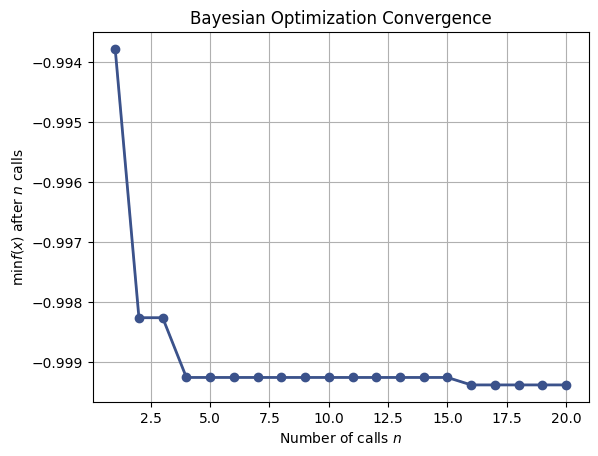

BAYESIAN SEARCH RESULTS:
Best Parameters: OrderedDict({'criterion': 'gini', 'max_depth': 21, 'max_features': 0.9655386200029669, 'min_samples_leaf': 5, 'n_estimators': 110})
Best CV Score (accuracy): 0.9994


In [41]:
plot_convergence(bayes_search.optimizer_results_)
plt.title("Bayesian Optimization Convergence")
plt.show()

# print optimal hyperparams from bayes search
print('BAYESIAN SEARCH RESULTS:')
print(f'Best Parameters: {bayes_search.best_params_}')
print(f'Best CV Score (accuracy): {bayes_search.best_score_:.4f}')

# 2. Extract the optimized model
# This model is already re-trained on the full training set using the best params
best_clf_bayes = bayes_search.best_estimator_

# 3. Predict on your validation set to see the real-world performance
y_val_pred_bayes = best_clf_bayes.predict(X_val)

# also predict on training set
y_train_pred_bayes = best_clf_bayes.predict(X_train)

Training   | Accuracy: 1.0000
Validation | Accuracy: 0.9991

--- Validation Classification Report ---
                   precision    recall  f1-score   support

    Highly Active       1.00      1.00      1.00       907
   Lightly Active       1.00      1.00      1.00       880
Moderately Active       1.00      1.00      1.00      1658

         accuracy                           1.00      3445
        macro avg       1.00      1.00      1.00      3445
     weighted avg       1.00      1.00      1.00      3445



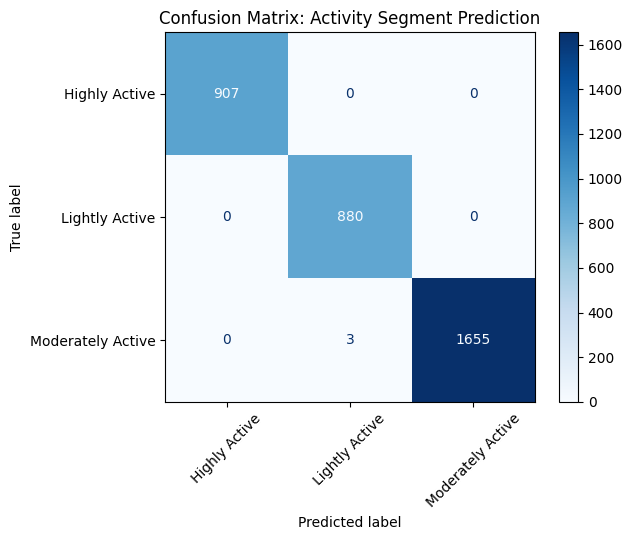

In [37]:
classification_eval(y_train,y_train_pred_bayes,y_val,y_val_pred_bayes)


The Bayesian optimization convergence plot shows that the model performance stabilizes after approximately 10–20 iterations, indicating that the search process has effectively converged and further iterations would likely yield only marginal improvements.  The model achieved a mean validation accuracy of approximately 0.9994, indicating strong and consistent performance across folds. Using the best hyperparameters identified through cross-validation, the final model was then evaluated on a separate hold-out dataset.


The training accuracy is 1.000 and validation accuracy is 0.9994. The confusion matrix reveals only 3 misclassifications out of 3445 samples, all of which involve moderately active individuals being misclassified as lightly active.


This small number of errors suggests that the model generalizes well, as there is minimal difference between training and validation performance, indicating no clear signs of overfitting. However, the near-perfect accuracy may also indicate that the classification problem is relatively simple or that the features are highly informative and strongly correlated with the target variable.

The misclassification pattern is also interpretable: moderately active individuals are occasionally classified as lightly active, likely due to overlapping feature ranges between these two groups. This is consistent with earlier EDA, where the distributions of these categories showed some degree of overlap.

Overall, the model demonstrates excellent predictive performance and stability across validation methods. However, given the unusually high accuracy, additional validation on a more complex or independent dataset would be beneficial to confirm its generalizability.

For the future model twisting, we can manually select only 1 explanatory varaible (num_steps_per_day) to do the prediction, it may reduce the overfitting problem.



Both Grid Search and Bayesian Optimization produced models with extremely high and nearly identical performance. The Grid Search achieved a cross-validation accuracy of 0.9993, while Bayesian Optimization slightly outperformed it with 0.9994. This small difference is negligible, indicating that both methods successfully identified highly effective hyperparameter configurations.

Despite the similar overall accuracy, the optimal hyperparameters differ between the two methods. Grid Search selected a more constrained model with max_depth = 10 and max_features = 'sqrt', while Bayesian Optimization favored a deeper model (max_depth = 21) with a larger feature subset (max_features ≈ 0.97) and additional regularization through min_samples_leaf = 5. 

The misclassification patterns are also slightly different between the two models, although the total number of errors remains very small. In both cases, most errors occur in the moderately active class, which is occasionally misclassified as either lightly active or highly active. This consistent pattern indicates that the moderate class likely overlaps with the other classes in the feature space, making it inherently more difficult to distinguish.
